# PnL focus

## 3. P&L Explained (élément central du métier)

Le point le plus important dans son discours est le **P&L explained**.

Chaque jour, un trader doit être capable d’expliquer précisément pourquoi il a gagné ou perdu de l’argent.

### 3.1 Décomposition du P&L

Le P&L est décomposé en contributions :

- Delta : impact des mouvements du sous-jacent
- Gamma : impact de la convexité (effet non linéaire)
- Vega : impact des variations de volatilité
- Theta : effet du passage du temps (décroissance)
- Effets d’ordre supérieur :
  - Vomma : sensibilité du Vega à la volatilité
  - Vanna : interaction entre prix et volatilité

### 3.2 Méthodes utilisées

Trois approches principales :

1. **Approche Taylor (approximation locale)**
   - Utilise les Greeks pour approximer le P&L
   - Rapide mais approximative
L’idée est d’approximer la variation de la valeur d’une option entre deux instants
$t$ et $t + \Delta t$ à l’aide d’un développement de Taylor.

On note :
- $V(S, \sigma, t)$ : valeur de l’option
- $\Delta S$ : variation du prix du sous-jacent
- $\Delta \sigma$ : variation de la volatilité implicite
- $\Delta t$ : variation du temps

Développement de Taylor (ordre 2) :

$$
\Delta V \approx
\underbrace{\Delta \cdot \Delta S}_{\text{effet Delta}}
+ \underbrace{\frac{1}{2} \Gamma \cdot (\Delta S)^2}_{\text{effet Gamma}}
+ \underbrace{\Theta \cdot \Delta t}_{\text{effet du temps}}
+ \underbrace{\text{Vega} \cdot \Delta \sigma}_{\text{effet volatilité}}
$$

Avec :
- $\Delta = \frac{\partial V}{\partial S}$
- $\Gamma = \frac{\partial^2 V}{\partial S^2}$
- $\Theta = \frac{\partial V}{\partial t}$
- $\text{Vega} = \frac{\partial V}{\partial \sigma}$

- **Delta** : variation linéaire due au mouvement du sous-jacent  
- **Gamma** : correction non-linéaire (convexité)  
- **Theta** : perte/gain lié au passage du temps (souvent négatif pour un acheteur)  
- **Vega** : impact d’un changement de volatilité implicite  

Forme simplifiée du P&L expliqué :

$$
P\&L \approx P\&L_{\Delta} + P\&L_{\Gamma} + P\&L_{\Theta} + P\&L_{\text{Vega}}
$$

| **Avantages** | **Limites** |
|--------------|------------|
| Très rapide à calculer | Approximation locale (valable pour petits mouvements) |
| Permet de **décomposer et expliquer le P&L** (très utilisé en pratique) | Moins précis si gros mouvements de prix |
| Donne une lecture intuitive via les Greeks | Moins précis si fortes variations de volatilité |
| Facile à implémenter | Moins adapté aux produits très non-linéaires |

2. **Approche par bump**
   - On modifie légèrement une variable (prix, vol)
   - On observe l’impact sur la valeur du portefeuille
On **fait varier légèrement une variable** (prix du sous-jacent, volatilité, taux, etc.)
et on **recalcule la valeur du portefeuille** pour mesurer l’impact.

$$
\text{Sensibilité} \approx \frac{V(x + \epsilon) - V(x)}{\epsilon}
$$

- Exemple :
  - Bump du prix → estimation du **Delta**
  - Bump de la vol → estimation du **Vega**

→ On mesure directement **l’impact réel** d’un petit changement de marché.
| **Avantages** | **Limites** |
|--------------|------------|
| Plus **précis** que Taylor si bien calibré | Plus **coûteux en calcul** (revalorisation nécessaire) |
| Facile à implémenter | Résultat dépend du choix de $\epsilon$ |
| Reflète mieux la réalité (pas d’approximation analytique directe) | Peut être instable si $\epsilon$ mal choisi |

3. **Full revaluation**
   - Recalcul complet du portefeuille avec nouvelles conditions de marché
   - Méthode la plus précise mais coûteuse
$$
P\&L = V_{\text{new}} - V_{\text{old}}
$$
→ On mesure directement la **variation réelle du portefeuille**, en prenant en compte
tous les effets (non-linéarités, interactions entre variables, structure des produits).
→ C’est la méthode la plus fiable, utilisée comme **référence**,  
mais elle est coûteuse en calcul et difficile à utiliser en temps réel sur de gros portefeuilles.

4. **Méthode simplifiée Delta**
   - P&L ≈ Delta(t-1) × (S_t - S_{t-1})
   - Permet d’isoler rapidement l’effet directionnel
On approxime le P&L en ne prenant en compte **que l’effet du mouvement du sous-jacent** via le Delta.

$$
P\&L \approx \Delta \cdot \Delta S
$$

→ On suppose que la variation de la valeur du portefeuille est **linéaire** par rapport au prix du sous-jacent.

→ Méthode **très rapide et intuitive**, mais **très approximative**, car elle ignore :
- la convexité (Gamma)
- la volatilité (Vega)
- le temps (Theta)

→ Utile pour une **estimation rapide**, mais insuffisant pour expliquer précisément le P&L.

Même logique pour Vega :
- Variation de volatilité → impact sur la valeur

Conclusion :
le trader doit comprendre non seulement le P&L total, mais aussi sa source précise.

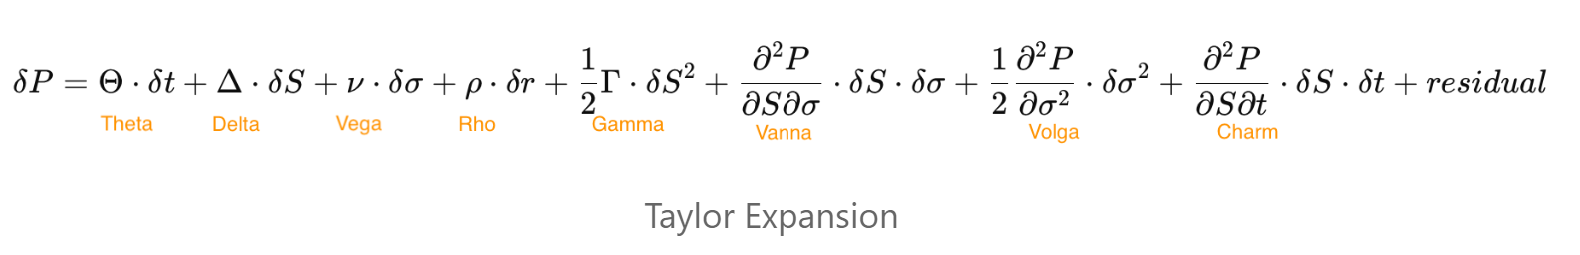

In an option portfolio, the P&L refers to the change in the portfolio's value over a small period of time. This change can be expressed as a function of various risk factors, such as the price of the underlying asset, volatility, interest rates, and time. The option Greeks quantify how the option price responds to each of these risk factors. Using a second-order Taylor expansion, we can decompose the P&L as follows: